In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()

SWINIR_DIR = PROJECT_DIR / "SwinIR"
CACHE_DIR = PROJECT_DIR / "dataset_cache"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
OUTPUT_DIR = PROJECT_DIR / "outputs"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT:", PROJECT_DIR)
print("CACHE:", CACHE_DIR)

PROJECT: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART
CACHE: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\dataset_cache


In [3]:
import subprocess

if not SWINIR_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/JingyunLiang/SwinIR.git",
            str(SWINIR_DIR)
        ],
        check=True
    )
else:
    print("SwinIR already exists.")

SwinIR already exists.


In [4]:
import os

os.chdir(SWINIR_DIR)

print(os.getcwd())

C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR


In [5]:
import os

print("Current directory:")
print(os.getcwd())

print("\nSwinIR exists:")
print(os.path.exists("main_test_swinir.py"))

Current directory:
C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR

SwinIR exists:
True


In [6]:
import sys

!"{sys.executable}" -m pip install timm einops opencv-python rasterio matplotlib numpy tqdm scikit-image tacoreader==0.4.5


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


STEP 3 — Download the pretrained ×4 model

We want the classical ×4 model, not the GAN real-world model.

Why?

Classical SR:
Lower hallucination risk
Better starting point for scientific reconstruction

GAN SR:
Sharper-looking images
Higher hallucination risk

In [7]:
from pathlib import Path

MODEL_DIR = SWINIR_DIR / "model_zoo" / "swinir"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(MODEL_DIR)

C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\model_zoo\swinir


In [8]:
import urllib.request

MODEL_URL = (
    "https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/"
    "001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth"
)

MODEL_PATH = (
    MODEL_DIR /
    "001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth"
)

if not MODEL_PATH.exists():

    print("Downloading model...")

    urllib.request.urlretrieve(
        MODEL_URL,
        MODEL_PATH
    )

else:

    print("Pretrained model already exists.")

print(MODEL_PATH)

Pretrained model already exists.
C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\model_zoo\swinir\001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth


In [9]:
print("Model exists:", MODEL_PATH.exists())
print("Model path:", MODEL_PATH)

Model exists: True
Model path: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\model_zoo\swinir\001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth


STEP 4 — Install the satellite dataset dependencies

SEN2NAIPv2 uses the TACO format and its dataset documentation recommends tacoreader and rasterio.

In [10]:
import tacoreader
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np

In [11]:
import sys

!"{sys.executable}" -m pip uninstall -y tacoreader
!"{sys.executable}" -m pip install tacoreader==0.4.5

Found existing installation: tacoreader 0.4.5
Uninstalling tacoreader-0.4.5:
  Successfully uninstalled tacoreader-0.4.5
  Using cached tacoreader-0.4.5-py3-none-any.whl (17 kB)



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
print(tacoreader.__version__)

0.4.5


In [13]:
dataset = tacoreader.load(
    "tacofoundation:sen2naipv2-unet"
)

print(dataset)

      internal:mode                                   internal:subfile  \
0            online  /vsisubfile/200_1195059,/vsicurl/https://huggi...   
1            online  /vsisubfile/1195259_1003267,/vsicurl/https://h...   
2            online  /vsisubfile/2198526_1133098,/vsicurl/https://h...   
3            online  /vsisubfile/3331624_1141332,/vsicurl/https://h...   
4            online  /vsisubfile/4472956_1016129,/vsicurl/https://h...   
...             ...                                                ...   
61277        online  /vsisubfile/19994241243_1018712,/vsicurl/https...   
61278        online  /vsisubfile/19995259955_1018679,/vsicurl/https...   
61279        online  /vsisubfile/19996278634_1063683,/vsicurl/https...   
61280        online  /vsisubfile/19997342317_1235765,/vsicurl/https...   
61281        online  /vsisubfile/19998578082_1277277,/vsicurl/https...   

                                           tortilla:id tortilla:file_format  \
0      NA5120_E1940N0771__m_4107

In [14]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [15]:
sample_idx = 4000

sample = dataset.read(sample_idx)

lr_path = sample.read(0)
hr_path = sample.read(1)

print("LR:", lr_path)
print("HR:", hr_path)

LR: /vsisubfile/4623289435_75411,/vsicurl/https://huggingface.co/datasets/tacofoundation/SEN2NAIPv2/resolve/main/sen2naipv2-unet.0003.part.taco
HR: /vsisubfile/4623364846_1075486,/vsicurl/https://huggingface.co/datasets/tacofoundation/SEN2NAIPv2/resolve/main/sen2naipv2-unet.0003.part.taco


In [16]:
sample = dataset.read(sample_idx)

lr_path = sample.read(0)
hr_path = sample.read(1)

In [17]:
with rio.open(lr_path) as src:

    lr_data = src.read(
        window=rio.windows.Window(
            0,
            0,
            64,
            64
        )
    )

with rio.open(hr_path) as src:

    hr_data = src.read(
        window=rio.windows.Window(
            0,
            0,
            256,
            256
        )
    )

In [18]:
print("LR shape:", lr_data.shape)
print("HR shape:", hr_data.shape)

LR shape: (4, 64, 64)
HR shape: (4, 256, 256)


In [19]:
def to_rgb(image):

    # Dataset order:
    # R = 0
    # G = 1
    # B = 2

    rgb = image[:3].transpose(1, 2, 0)

    rgb = rgb / 3000.0

    return np.clip(rgb, 0, 1)

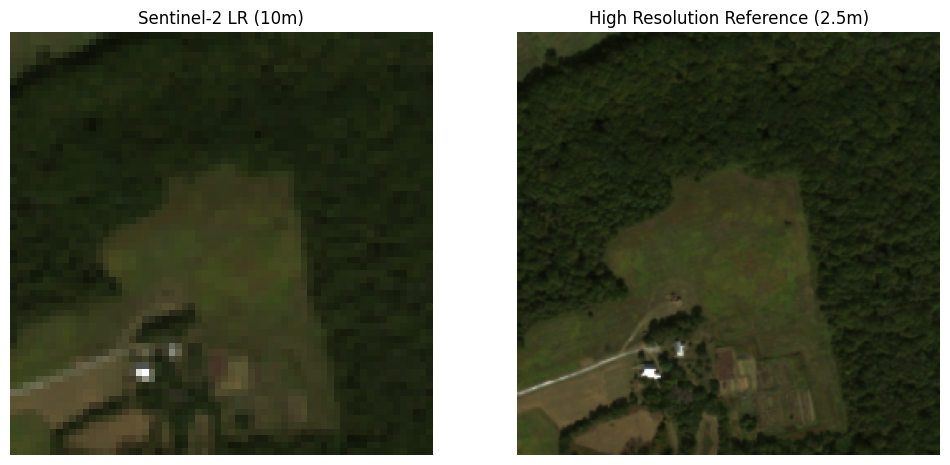

In [20]:
lr_rgb = to_rgb(lr_data)
hr_rgb = to_rgb(hr_data)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)

plt.imshow(lr_rgb)
plt.title("Sentinel-2 LR (10m)")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(hr_rgb)
plt.title("High Resolution Reference (2.5m)")
plt.axis("off")

plt.show()

In [21]:
import torch

from torch.utils.data import Dataset

In [22]:
class SatelliteSRDataset(Dataset):

    def __init__(
        self,
        taco_dataset,
        indices
    ):

        self.dataset = taco_dataset

        self.indices = indices


    def __len__(self):

        return len(self.indices)


    def __getitem__(self, idx):

        sample_idx = self.indices[idx]

        sample = self.dataset.read(sample_idx)

        lr_path = sample.read(0)
        hr_path = sample.read(1)


        # -----------------------
        # READ LOW RESOLUTION
        # -----------------------

        with rio.open(lr_path) as src:

            lr = src.read(
                window=rio.windows.Window(
                    0,
                    0,
                    64,
                    64
                )
            )


        # -----------------------
        # READ HIGH RESOLUTION
        # -----------------------

        with rio.open(hr_path) as src:

            hr = src.read(
                window=rio.windows.Window(
                    0,
                    0,
                    256,
                    256
                )
            )


        # -----------------------
        # SELECT RGB
        # -----------------------

        lr = lr[:3]

        hr = hr[:3]


        # -----------------------
        # CONVERT TO TENSOR
        # -----------------------

        lr = torch.tensor(
            lr,
            dtype=torch.float32
        )

        hr = torch.tensor(
            hr,
            dtype=torch.float32
        )


        # -----------------------
        # NORMALIZATION
        # -----------------------

        lr = lr / 3000.0

        hr = hr / 3000.0


        # -----------------------
        # CLAMP
        # -----------------------

        lr = torch.clamp(
            lr,
            0,
            1
        )

        hr = torch.clamp(
            hr,
            0,
            1
        )


        return lr, hr

In [23]:
train_indices = list(range(0, 500))

val_indices = list(range(500, 600))

test_indices = list(range(600, 700))

In [24]:
train_dataset = SatelliteSRDataset(
    dataset,
    train_indices
)

val_dataset = SatelliteSRDataset(
    dataset,
    val_indices
)

test_dataset = SatelliteSRDataset(
    dataset,
    test_indices
)

In [25]:
import os
from pathlib import Path

# PROJECT_DIR should already have been created earlier.
# If not, this sets it to the folder containing/running the notebook.
PROJECT_DIR = Path.cwd()

# Local Windows cache folder
CACHE_DIR = PROJECT_DIR / "dataset_cache"

# Training folders
TRAIN_LR_DIR = CACHE_DIR / "train" / "lr"
TRAIN_HR_DIR = CACHE_DIR / "train" / "hr"

# Validation folders
VAL_LR_DIR = CACHE_DIR / "val" / "lr"
VAL_HR_DIR = CACHE_DIR / "val" / "hr"

# Test folders
TEST_LR_DIR = CACHE_DIR / "test" / "lr"
TEST_HR_DIR = CACHE_DIR / "test" / "hr"


# Create all folders
for directory in [
    TRAIN_LR_DIR,
    TRAIN_HR_DIR,
    VAL_LR_DIR,
    VAL_HR_DIR,
    TEST_LR_DIR,
    TEST_HR_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)


print("Cache folders created!")
print("Cache location:", CACHE_DIR)

Cache folders created!
Cache location: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\dataset_cache


In [26]:
def count_cached(directory):
    return len(list(Path(directory).glob("*.pt")))


print("Train LR cached:", count_cached(TRAIN_LR_DIR))
print("Train HR cached:", count_cached(TRAIN_HR_DIR))

print("Val LR cached:", count_cached(VAL_LR_DIR))
print("Val HR cached:", count_cached(VAL_HR_DIR))

print("Test LR cached:", count_cached(TEST_LR_DIR))
print("Test HR cached:", count_cached(TEST_HR_DIR))

Train LR cached: 500
Train HR cached: 500
Val LR cached: 100
Val HR cached: 100
Test LR cached: 100
Test HR cached: 100


In [27]:
import torch
from tqdm import tqdm


def cache_dataset_local(dataset, lr_dir, hr_dir):

    lr_dir = Path(lr_dir)
    hr_dir = Path(hr_dir)

    for i in tqdm(range(len(dataset))):

        lr_path = lr_dir / f"{i:06d}.pt"
        hr_path = hr_dir / f"{i:06d}.pt"

        # Skip if both files already exist
        if lr_path.exists() and hr_path.exists():
            continue

        lr, hr = dataset[i]

        # Save only missing files
        if not lr_path.exists():
            torch.save(lr.cpu(), lr_path)

        if not hr_path.exists():
            torch.save(hr.cpu(), hr_path)

In [28]:
cache_dataset_local(
    train_dataset,
    TRAIN_LR_DIR,
    TRAIN_HR_DIR
)

100%|██████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 1496.24it/s]


In [29]:
print("Train LR:", count_cached(TRAIN_LR_DIR))
print("Train HR:", count_cached(TRAIN_HR_DIR))

Train LR: 500
Train HR: 500


In [30]:
cache_dataset_local(
    val_dataset,
    VAL_LR_DIR,
    VAL_HR_DIR
)

100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1297.94it/s]


In [31]:
print("Val LR:", count_cached(VAL_LR_DIR))
print("Val HR:", count_cached(VAL_HR_DIR))

Val LR: 100
Val HR: 100


In [32]:
cache_dataset_local(
    test_dataset,
    TEST_LR_DIR,
    TEST_HR_DIR
)

100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1404.55it/s]


In [33]:
print("Test LR:", count_cached(TEST_LR_DIR))
print("Test HR:", count_cached(TEST_HR_DIR))

Test LR: 100
Test HR: 100


In [34]:
print("TRAIN")
print("LR:", count_cached(TRAIN_LR_DIR))
print("HR:", count_cached(TRAIN_HR_DIR))

print("\nVALIDATION")
print("LR:", count_cached(VAL_LR_DIR))
print("HR:", count_cached(VAL_HR_DIR))

print("\nTEST")
print("LR:", count_cached(TEST_LR_DIR))
print("HR:", count_cached(TEST_HR_DIR))

TRAIN
LR: 500
HR: 500

VALIDATION
LR: 100
HR: 100

TEST
LR: 100
HR: 100


In [35]:
from torch.utils.data import Dataset
from pathlib import Path
import torch


class LocalSatelliteSRDataset(Dataset):

    def __init__(self, lr_dir, hr_dir):

        self.lr_dir = Path(lr_dir)
        self.hr_dir = Path(hr_dir)

        self.lr_files = sorted(
            self.lr_dir.glob("*.pt")
        )

        self.hr_files = sorted(
            self.hr_dir.glob("*.pt")
        )

        assert len(self.lr_files) == len(self.hr_files), \
            "LR and HR file counts do not match!"

    def __len__(self):

        return len(self.lr_files)

    def __getitem__(self, index):

        lr = torch.load(
            self.lr_files[index],
            map_location="cpu"
        )

        hr = torch.load(
            self.hr_files[index],
            map_location="cpu"
        )

        return lr.float(), hr.float()

In [36]:
local_train_dataset = LocalSatelliteSRDataset(
    TRAIN_LR_DIR,
    TRAIN_HR_DIR
)

local_val_dataset = LocalSatelliteSRDataset(
    VAL_LR_DIR,
    VAL_HR_DIR
)

local_test_dataset = LocalSatelliteSRDataset(
    TEST_LR_DIR,
    TEST_HR_DIR
)


print("Train:", len(local_train_dataset))
print("Validation:", len(local_val_dataset))
print("Test:", len(local_test_dataset))

Train: 500
Validation: 100
Test: 100


In [37]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(
    local_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # IMPORTANT for Windows/Jupyter
    pin_memory=True
)

val_loader = DataLoader(
    local_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    local_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [38]:
lr_batch, hr_batch = next(iter(train_loader))

print("LR batch shape:", lr_batch.shape)
print("HR batch shape:", hr_batch.shape)

LR batch shape: torch.Size([4, 3, 64, 64])
HR batch shape: torch.Size([4, 3, 256, 256])


In [39]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [40]:
import os

os.chdir(SWINIR_DIR)

print("Current directory:", os.getcwd())

Current directory: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR


In [41]:
from models.network_swinir import SwinIR

C:\Users\Anuj Pethe\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [42]:
model = SwinIR(
    upscale=4,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6, 6, 6],
    embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

C:\Users\Anuj Pethe\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [43]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

print(checkpoint.keys())

dict_keys(['params'])


In [44]:
state_dict = checkpoint["params"].copy()

# Remove dynamically generated attention masks
for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

# Load remaining pretrained weights
missing_keys, unexpected_keys = model.load_state_dict(
    state_dict,
    strict=False
)

print("Pretrained SwinIR loaded successfully!")

print("\nMissing keys:")
print(missing_keys)

print("\nUnexpected keys:")
print(unexpected_keys)

Pretrained SwinIR loaded successfully!

Missing keys:
['layers.0.residual_group.blocks.1.attn_mask', 'layers.0.residual_group.blocks.3.attn_mask', 'layers.0.residual_group.blocks.5.attn_mask', 'layers.1.residual_group.blocks.1.attn_mask', 'layers.1.residual_group.blocks.3.attn_mask', 'layers.1.residual_group.blocks.5.attn_mask', 'layers.2.residual_group.blocks.1.attn_mask', 'layers.2.residual_group.blocks.3.attn_mask', 'layers.2.residual_group.blocks.5.attn_mask', 'layers.3.residual_group.blocks.1.attn_mask', 'layers.3.residual_group.blocks.3.attn_mask', 'layers.3.residual_group.blocks.5.attn_mask', 'layers.4.residual_group.blocks.1.attn_mask', 'layers.4.residual_group.blocks.3.attn_mask', 'layers.4.residual_group.blocks.5.attn_mask', 'layers.5.residual_group.blocks.1.attn_mask', 'layers.5.residual_group.blocks.3.attn_mask', 'layers.5.residual_group.blocks.5.attn_mask']

Unexpected keys:
[]


In [45]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cuda


In [46]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

model = model.to(device)

Using: cuda


In [47]:
print(next(model.parameters()).device)

cuda:0


In [48]:
import torch.nn as nn

criterion = nn.L1Loss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [49]:
from pathlib import Path

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_swinir_sen2naip.pth"
LATEST_MODEL_PATH = CHECKPOINT_DIR / "latest_swinir_sen2naip.pth"

print("Best model path:", BEST_MODEL_PATH)
print("Latest model path:", LATEST_MODEL_PATH)

Best model path: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\checkpoints\best_swinir_sen2naip.pth
Latest model path: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\checkpoints\latest_swinir_sen2naip.pth


In [50]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

print("LR input:", lr_batch.shape)
print("HR target:", hr_batch.shape)

with torch.cuda.amp.autocast():
    output = model(lr_batch)

print("Model output:", output.shape)

LR input: torch.Size([4, 3, 64, 64])
HR target: torch.Size([4, 3, 256, 256])


C:\Users\Anuj Pethe\AppData\Local\Temp\ipykernel_7420\1926015031.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Model output: torch.Size([4, 3, 256, 256])


In [51]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device, non_blocking=True)
hr_batch = hr_batch.to(device, non_blocking=True)

optimizer.zero_grad()

with torch.amp.autocast("cuda"):
    output = model(lr_batch)
    loss = criterion(output, hr_batch)

print("Loss:", loss.item())

loss.backward()

optimizer.step()

print("One training step completed successfully!")

Loss: nan
One training step completed successfully!


In [52]:
lr_batch, hr_batch = next(iter(train_loader))

print("LR has NaN:", torch.isnan(lr_batch).any().item())
print("LR has Inf:", torch.isinf(lr_batch).any().item())
print("LR min:", lr_batch.min().item())
print("LR max:", lr_batch.max().item())

print()

print("HR has NaN:", torch.isnan(hr_batch).any().item())
print("HR has Inf:", torch.isinf(hr_batch).any().item())
print("HR min:", hr_batch.min().item())
print("HR max:", hr_batch.max().item())

LR has NaN: False
LR has Inf: False
LR min: 0.024000000208616257
LR max: 1.0

HR has NaN: False
HR has Inf: False
HR min: 0.0026666666381061077
HR max: 1.0


In [53]:
checkpoint = torch.load(MODEL_PATH, map_location="cpu")
state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)
model = model.to(device)

print("Fresh pretrained model reloaded!")

Fresh pretrained model reloaded!


In [54]:
model.eval()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

with torch.no_grad():
    output = model(lr_batch)

print("Output has NaN:", torch.isnan(output).any().item())
print("Output has Inf:", torch.isinf(output).any().item())

print("Output min:", output.min().item())
print("Output max:", output.max().item())

loss = criterion(output, hr_batch)

print("Loss:", loss.item())
print("Loss is NaN:", torch.isnan(loss).item())

Output has NaN: False
Output has Inf: False
Output min: 0.029063761234283447
Output max: 0.9724427461624146
Loss: 0.01598794013261795
Loss is NaN: False


In [55]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device, non_blocking=True)
hr_batch = hr_batch.to(device, non_blocking=True)

optimizer.zero_grad()

# Normal FP32 forward pass — NO AMP
output = model(lr_batch)

loss = criterion(output, hr_batch)

print("Loss before backward:", loss.item())

loss.backward()

optimizer.step()

print("Training step completed!")

# Check model parameters for NaN
has_nan = any(
    torch.isnan(param).any().item()
    for param in model.parameters()
)

print("Model has NaN parameters:", has_nan)

Loss before backward: 0.012821158394217491
Training step completed!
Model has NaN parameters: True


In [56]:
checkpoint = torch.load(MODEL_PATH, map_location="cpu")
state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)
model = model.to(device)

print("Fresh pretrained model loaded!")

Fresh pretrained model loaded!


In [57]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

optimizer.zero_grad()

output = model(lr_batch)
loss = criterion(output, hr_batch)

print("Loss:", loss.item())

loss.backward()

has_nan_grad = False
has_inf_grad = False

for name, param in model.named_parameters():

    if param.grad is not None:

        if torch.isnan(param.grad).any():
            print("NaN gradient found in:", name)
            has_nan_grad = True
            break

        if torch.isinf(param.grad).any():
            print("Inf gradient found in:", name)
            has_inf_grad = True
            break


print("Has NaN gradients:", has_nan_grad)
print("Has Inf gradients:", has_inf_grad)

Loss: 0.01490107737481594
Has NaN gradients: False
Has Inf gradients: False


In [58]:
# Reload clean pretrained weights
checkpoint = torch.load(MODEL_PATH, map_location="cpu")
state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)
model = model.to(device)

# IMPORTANT: create a completely fresh optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

print("Clean model and fresh optimizer ready!")

Clean model and fresh optimizer ready!


In [59]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

optimizer.zero_grad()

# Forward pass
output = model(lr_batch)

# Loss
loss = criterion(output, hr_batch)

print("Loss before update:", loss.item())

# Backpropagation
loss.backward()

# Gradient clipping
grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

print("Gradient norm:", grad_norm.item())

# Update
optimizer.step()

# Check parameters
has_nan = any(
    torch.isnan(param).any().item()
    for param in model.parameters()
)

has_inf = any(
    torch.isinf(param).any().item()
    for param in model.parameters()
)

print("Model has NaN:", has_nan)
print("Model has Inf:", has_inf)

Loss before update: 0.02389235608279705
Gradient norm: 0.17549920082092285
Model has NaN: False
Model has Inf: False


In [60]:
checkpoint = torch.load(MODEL_PATH, map_location="cpu")

state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)

model = model.to(device)

print("Fresh pretrained model restored!")

Fresh pretrained model restored!


In [61]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

criterion = nn.L1Loss()

print("Fresh optimizer ready!")

Fresh optimizer ready!


In [63]:
import torch

checkpoint = torch.load(
    LATEST_MODEL_PATH,
    map_location=device
)

print("Checkpoint epoch:", checkpoint["epoch"])
print("Checkpoint train loss:", checkpoint["train_loss"])
print("Checkpoint validation loss:", checkpoint["val_loss"])

Checkpoint epoch: 1
Checkpoint train loss: 0.017275489915162326
Checkpoint validation loss: 0.01753138853237033


In [64]:
checkpoint = torch.load(
    LATEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]
best_val_loss = checkpoint["val_loss"]

print("Resuming from epoch:", start_epoch)
print("Next epoch will be:", start_epoch + 1)

Resuming from epoch: 1
Next epoch will be: 2


In [65]:
from tqdm import tqdm
import torch

best_val_loss = float("inf")
EPOCHS = 5

for epoch in range(start_epoch, EPOCHS):

    # =========================
    # TRAINING
    # =========================

    model.train()

    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} Training"
    )

    for lr_batch, hr_batch in train_bar:

        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        hr_batch = hr_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        # Forward pass
        output = model(lr_batch)

        # Calculate loss
        loss = criterion(
            output,
            hr_batch
        )

        # Safety check
        if torch.isnan(loss) or torch.isinf(loss):
            print("\nInvalid loss detected. Skipping batch.")
            continue

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.5f}"
        )


    avg_train_loss = (
        train_loss /
        len(train_loader)
    )


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch + 1}/{EPOCHS} Validation"
        )

        for lr_batch, hr_batch in val_bar:

            lr_batch = lr_batch.to(
                device,
                non_blocking=True
            )

            hr_batch = hr_batch.to(
                device,
                non_blocking=True
            )

            output = model(lr_batch)

            loss = criterion(
                output,
                hr_batch
            )

            if torch.isnan(loss) or torch.isinf(loss):
                print(
                    "\nInvalid validation loss detected."
                )
                continue

            val_loss += loss.item()


    avg_val_loss = (
        val_loss /
        len(val_loader)
    )


    # =========================
    # SAVE LATEST CHECKPOINT
    # =========================

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "train_loss":
                avg_train_loss,

            "val_loss":
                avg_val_loss
        },

        LATEST_MODEL_PATH
    )


    # =========================
    # SAVE BEST CHECKPOINT
    # =========================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "train_loss":
                    avg_train_loss,

                "val_loss":
                    avg_val_loss
            },

            BEST_MODEL_PATH
        )

        print(
            f"\n⭐ New best model saved!"
        )


    # =========================
    # EPOCH RESULTS
    # =========================

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: "
        f"{avg_train_loss:.6f}"
    )

    print(
        f"Validation Loss: "
        f"{avg_val_loss:.6f}"
    )

    print(
        f"Best Validation Loss: "
        f"{best_val_loss:.6f}"
    )

Epoch 2/5 Validation: 100%|████████████████████████████████████████████████████████████| 25/25 [00:12<00:00,  1.97it/s]



⭐ New best model saved!

Epoch 2/5
Train Loss: 0.016832
Validation Loss: 0.017334
Best Validation Loss: 0.017334


Epoch 3/5 Validation: 100%|████████████████████████████████████████████████████████████| 25/25 [00:27<00:00,  1.08s/it]



⭐ New best model saved!

Epoch 3/5
Train Loss: 0.016689
Validation Loss: 0.017213
Best Validation Loss: 0.017213


Epoch 4/5 Validation: 100%|████████████████████████████████████████████████████████████| 25/25 [00:08<00:00,  3.07it/s]



⭐ New best model saved!

Epoch 4/5
Train Loss: 0.016586
Validation Loss: 0.017143
Best Validation Loss: 0.017143


Epoch 5/5 Validation: 100%|████████████████████████████████████████████████████████████| 25/25 [00:08<00:00,  3.07it/s]



⭐ New best model saved!

Epoch 5/5
Train Loss: 0.016511
Validation Loss: 0.017063
Best Validation Loss: 0.017063


In [66]:
from pathlib import Path
import torch

print("Best model exists:", BEST_MODEL_PATH.exists())
print("Latest model exists:", LATEST_MODEL_PATH.exists())

if BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location="cpu")

    print("\nBEST CHECKPOINT INFO")
    print("Saved epoch:", checkpoint["epoch"])
    print("Train loss:", checkpoint["train_loss"])
    print("Validation loss:", checkpoint["val_loss"])

if LATEST_MODEL_PATH.exists():
    checkpoint = torch.load(LATEST_MODEL_PATH, map_location="cpu")

    print("\nLATEST CHECKPOINT INFO")
    print("Saved epoch:", checkpoint["epoch"])
    print("Train loss:", checkpoint["train_loss"])
    print("Validation loss:", checkpoint["val_loss"])

Best model exists: True
Latest model exists: True

BEST CHECKPOINT INFO
Saved epoch: 5
Train loss: 0.016510978884994983
Validation loss: 0.01706277685239911

LATEST CHECKPOINT INFO
Saved epoch: 5
Train loss: 0.016510978884994983
Validation loss: 0.01706277685239911


In [67]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best checkpoint loaded!")
print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

Best checkpoint loaded!
Epoch: 5
Validation loss: 0.01706277685239911


In [68]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

print("Evaluation libraries ready!")

Evaluation libraries ready!


In [69]:
model.eval()

bicubic_psnr = []
bicubic_ssim = []
bicubic_rmse = []

swinir_psnr = []
swinir_ssim = []
swinir_rmse = []


with torch.no_grad():

    test_bar = tqdm(
        test_loader,
        desc="Evaluating test set"
    )

    for lr_batch, hr_batch in test_bar:

        # Move only LR to GPU
        lr_gpu = lr_batch.to(
            device,
            non_blocking=True
        )

        # -------------------------
        # SwinIR prediction
        # -------------------------

        swinir_output = model(lr_gpu)

        # Move prediction to CPU
        swinir_output = swinir_output.cpu()

        # -------------------------
        # Bicubic baseline
        # -------------------------

        bicubic_output = F.interpolate(
            lr_batch,
            size=hr_batch.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        # Clamp generated output
        swinir_output = torch.clamp(
            swinir_output,
            0.0,
            1.0
        )

        bicubic_output = torch.clamp(
            bicubic_output,
            0.0,
            1.0
        )

        # -------------------------
        # Evaluate each image
        # -------------------------

        for i in range(lr_batch.shape[0]):

            target = (
                hr_batch[i]
                .permute(1, 2, 0)
                .numpy()
            )

            bicubic_img = (
                bicubic_output[i]
                .permute(1, 2, 0)
                .numpy()
            )

            swinir_img = (
                swinir_output[i]
                .permute(1, 2, 0)
                .numpy()
            )

            # PSNR
            bicubic_psnr.append(
                peak_signal_noise_ratio(
                    target,
                    bicubic_img,
                    data_range=1.0
                )
            )

            swinir_psnr.append(
                peak_signal_noise_ratio(
                    target,
                    swinir_img,
                    data_range=1.0
                )
            )

            # SSIM
            bicubic_ssim.append(
                structural_similarity(
                    target,
                    bicubic_img,
                    channel_axis=2,
                    data_range=1.0
                )
            )

            swinir_ssim.append(
                structural_similarity(
                    target,
                    swinir_img,
                    channel_axis=2,
                    data_range=1.0
                )
            )

            # RMSE
            bicubic_rmse.append(
                np.sqrt(
                    np.mean(
                        (target - bicubic_img) ** 2
                    )
                )
            )

            swinir_rmse.append(
                np.sqrt(
                    np.mean(
                        (target - swinir_img) ** 2
                    )
                )
            )


print("\n===== BICUBIC =====")

print(
    "PSNR :",
    np.mean(bicubic_psnr)
)

print(
    "SSIM :",
    np.mean(bicubic_ssim)
)

print(
    "RMSE :",
    np.mean(bicubic_rmse)
)


print("\n===== FINE-TUNED SWINIR =====")

print(
    "PSNR :",
    np.mean(swinir_psnr)
)

print(
    "SSIM :",
    np.mean(swinir_ssim)
)

print(
    "RMSE :",
    np.mean(swinir_rmse)
)

Evaluating test set: 100%|█████████████████████████████████████████████████████████████| 25/25 [00:21<00:00,  1.17it/s]


===== BICUBIC =====
PSNR : 31.60811543179592
SSIM : 0.78605723
RMSE : 0.030692967

===== FINE-TUNED SWINIR =====
PSNR : 33.512147037817314
SSIM : 0.855451
RMSE : 0.024446152


In [74]:
import numpy as np

best_index = 0
best_variance = 0

# Check first 100 test samples
num_samples = min(100, len(local_test_dataset))

for i in range(num_samples):

    lr_img, hr_img = local_test_dataset[i]

    img = hr_img.numpy()

    variance = np.var(img)

    if variance > best_variance:
        best_variance = variance
        best_index = i


print("Selected sample index:", best_index)
print("Image variance:", best_variance)

Selected sample index: 7
Image variance: 0.022683365


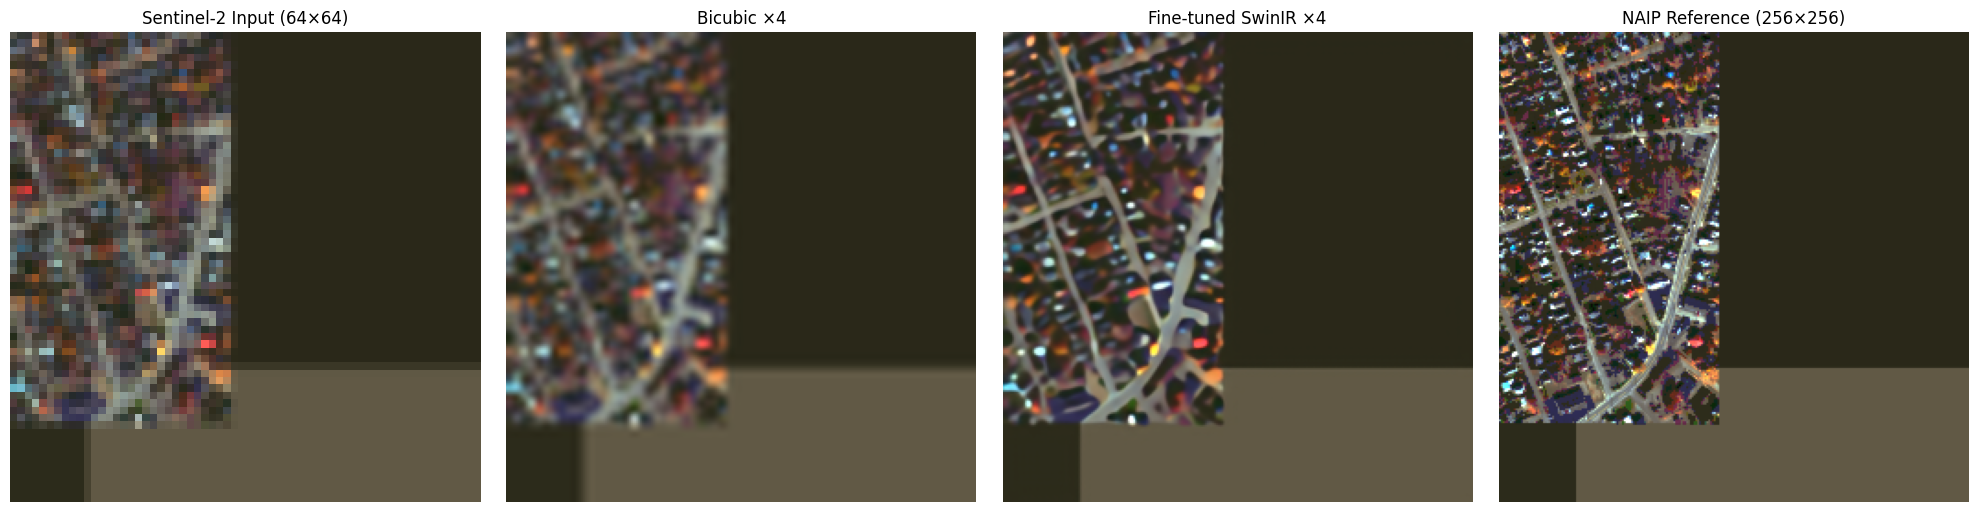

In [75]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

# Choose one unseen test sample
sample_index = best_index

lr_img, hr_img = local_test_dataset[sample_index]

# Add batch dimension and move LR to GPU
lr_input = lr_img.unsqueeze(0).to(device)

# Generate SwinIR output
model.eval()

with torch.no_grad():
    swinir_img = model(lr_input).cpu().squeeze(0)

# Bicubic upscaling
bicubic_img = F.interpolate(
    lr_img.unsqueeze(0),
    size=hr_img.shape[-2:],
    mode="bicubic",
    align_corners=False
).squeeze(0)

# Clamp outputs
swinir_img = torch.clamp(swinir_img, 0, 1)
bicubic_img = torch.clamp(bicubic_img, 0, 1)

# Convert CHW → HWC for plotting
lr_plot = lr_img.permute(1, 2, 0).numpy()
bicubic_plot = bicubic_img.permute(1, 2, 0).numpy()
swinir_plot = swinir_img.permute(1, 2, 0).numpy()
hr_plot = hr_img.permute(1, 2, 0).numpy()

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(lr_plot)
axes[0].set_title("Sentinel-2 Input (64×64)")
axes[0].axis("off")

axes[1].imshow(bicubic_plot)
axes[1].set_title("Bicubic ×4")
axes[1].axis("off")

axes[2].imshow(swinir_plot)
axes[2].set_title("Fine-tuned SwinIR ×4")
axes[2].axis("off")

axes[3].imshow(hr_plot)
axes[3].set_title("NAIP Reference (256×256)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

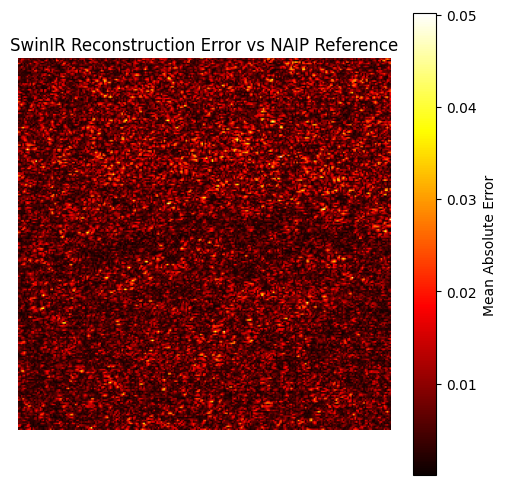

Mean Absolute Error: 0.007362172
Maximum Error: 0.050167322


In [71]:
# Absolute error map between prediction and real NAIP reference

error_map = np.mean(
    np.abs(swinir_plot - hr_plot),
    axis=2
)

plt.figure(figsize=(6, 6))

plt.imshow(error_map, cmap="hot")

plt.colorbar(
    label="Mean Absolute Error"
)

plt.title(
    "SwinIR Reconstruction Error vs NAIP Reference"
)

plt.axis("off")

plt.show()

print("Mean Absolute Error:", error_map.mean())
print("Maximum Error:", error_map.max())

In [79]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def super_resolve_sentinel2(lr_image, model, device):
    """
    Input:
        lr_image : Torch tensor of shape [3, H, W]
                   Values should be normalized to [0, 1]

    Output:
        sr_image : Super-resolved image
                   Shape [3, H*4, W*4]
    """

    model.eval()

    # Add batch dimension
    input_tensor = lr_image.unsqueeze(0).to(device)

    # Run inference
    with torch.no_grad():
        output = model(input_tensor)

    # Remove batch dimension and move to CPU
    output = output.squeeze(0).cpu()

    # Keep pixel values valid
    output = torch.clamp(output, 0.0, 1.0)

    return output


print("Inference function ready!")

Inference function ready!


In [80]:
sample_index = 10

lr_img, hr_img = local_test_dataset[sample_index]

sr_img = super_resolve_sentinel2(
    lr_img,
    model,
    device
)

print("Input shape:", lr_img.shape)
print("Super-resolved shape:", sr_img.shape)
print("Reference shape:", hr_img.shape)

Input shape: torch.Size([3, 64, 64])
Super-resolved shape: torch.Size([3, 256, 256])
Reference shape: torch.Size([3, 256, 256])


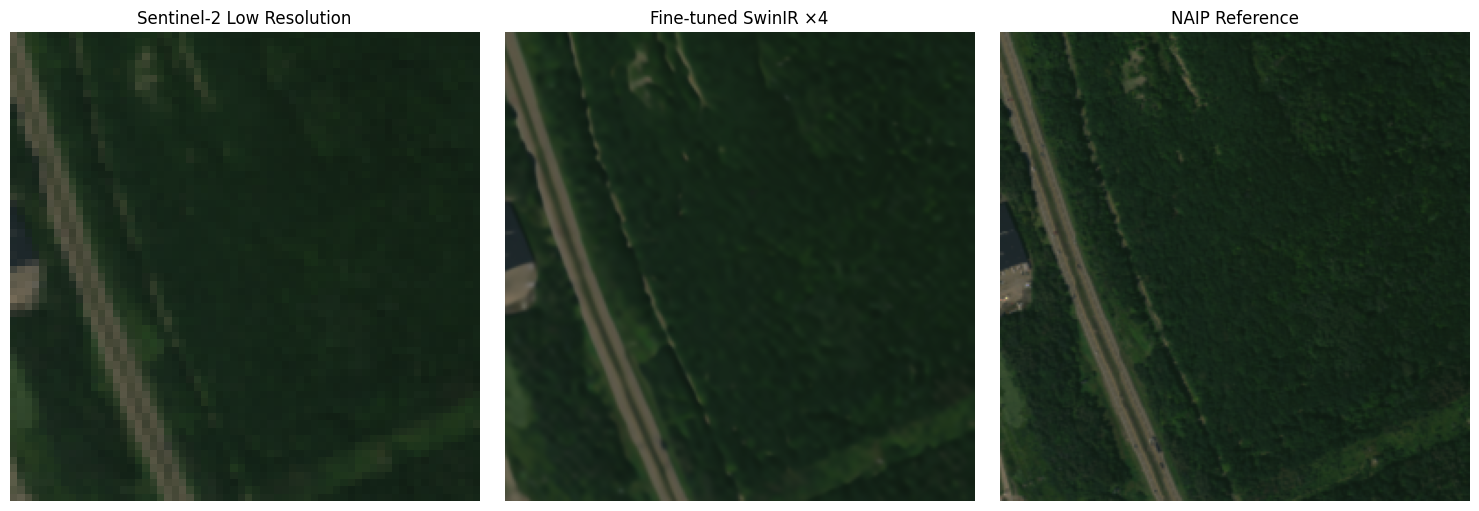

In [81]:
lr_plot = lr_img.permute(1, 2, 0).numpy()
sr_plot = sr_img.permute(1, 2, 0).numpy()
hr_plot = hr_img.permute(1, 2, 0).numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(lr_plot)
plt.title("Sentinel-2 Low Resolution")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sr_plot)
plt.title("Fine-tuned SwinIR ×4")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hr_plot)
plt.title("NAIP Reference")
plt.axis("off")

plt.tight_layout()
plt.show()

In [82]:
sample_index = 10

lr_img, hr_img = local_test_dataset[sample_index]

sr_img = super_resolve_sentinel2(
    lr_img,
    model,
    device
)

print("Input shape:", lr_img.shape)
print("Output shape:", sr_img.shape)

Input shape: torch.Size([3, 64, 64])
Output shape: torch.Size([3, 256, 256])


In [83]:
import os
import torch

DEPLOYMENT_DIR = "deployment_model"

os.makedirs(
    DEPLOYMENT_DIR,
    exist_ok=True
)

DEPLOYMENT_MODEL_PATH = os.path.join(
    DEPLOYMENT_DIR,
    "swinir_sentinel2_x4.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "scale": 4,
        "input_channels": 3,
        "input_size": 64,
        "output_size": 256,
        "normalization_range": [0, 1]
    },
    DEPLOYMENT_MODEL_PATH
)

print("Deployment model saved!")
print(DEPLOYMENT_MODEL_PATH)

Deployment model saved!
deployment_model\swinir_sentinel2_x4.pth


In [84]:
# Create a completely fresh SwinIR model

deploy_model = SwinIR(
    upscale=4,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6, 6, 6],
    embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

deploy_model = deploy_model.to(device)

print("Fresh SwinIR model created!")

Fresh SwinIR model created!


In [85]:
checkpoint = torch.load(
    DEPLOYMENT_MODEL_PATH,
    map_location=device
)

deploy_model.load_state_dict(
    checkpoint["model_state_dict"]
)

deploy_model.eval()

print("Deployment model loaded successfully!")

Deployment model loaded successfully!


In [86]:
test_input = lr_img.unsqueeze(0).to(device)

with torch.no_grad():
    test_output = deploy_model(test_input)

print("Input:", test_input.shape)
print("Output:", test_output.shape)

Input: torch.Size([1, 3, 64, 64])
Output: torch.Size([1, 3, 256, 256])


In [87]:
import json

MODEL_CONFIG = {
    "model": "SwinIR",
    "task": "Classical Image Super Resolution",
    "scale_factor": 4,
    "input_channels": 3,
    "training_input_size": [64, 64],
    "training_output_size": [256, 256],
    "normalization": "[0, 1]",
    "dataset": "SEN2NAIP",
    "pretrained_model": "SwinIR Classical SR x4",
    "epochs": 5
}

with open(
    "deployment_model/model_config.json",
    "w"
) as f:
    json.dump(
        MODEL_CONFIG,
        f,
        indent=4
    )

print("Model configuration saved!")

Model configuration saved!


In [88]:
import torch


def run_swinir_inference(
    image_tensor,
    model,
    device
):

    model.eval()

    # Expected input:
    # [3, H, W]

    input_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

    output = (
        output
        .squeeze(0)
        .cpu()
    )

    output = torch.clamp(
        output,
        0.0,
        1.0
    )

    return output


print("Inference pipeline ready!")

Inference pipeline ready!


In [89]:
sr_result = run_swinir_inference(
    lr_img,
    deploy_model,
    device
)

print(
    "Final output shape:",
    sr_result.shape
)

Final output shape: torch.Size([3, 256, 256])


In [90]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR

Files/folders here:
['.git', 'checkpoints', 'cog.yaml', 'dataset_cache', 'deployment_model', 'download-weights.sh', 'figs', 'LICENSE', 'main_test_swinir.py', 'models', 'model_zoo', 'outputs', 'predict.py', 'README.md', 'SwinIR', 'testsets', 'utils']


In [91]:
import torch
from tqdm.auto import tqdm

# Make sure model is in evaluation mode
model.eval()

total_samples = 0
failed_samples = 0
nan_outputs = 0
wrong_shape_outputs = 0

expected_input_shape = (3, 64, 64)
expected_output_shape = (3, 256, 256)

print("Running final robustness test on ALL test samples...\n")

with torch.no_grad():

    for i in tqdm(range(len(test_dataset))):

        try:
            # Get one unseen Sentinel-2 test sample
            lr, hr = test_dataset[i]

            # Check input
            if tuple(lr.shape) != expected_input_shape:
                print(
                    f"\nSample {i}: Unexpected input shape: {lr.shape}"
                )

            # Add batch dimension and move to GPU
            lr_input = lr.unsqueeze(0).to(device)

            # Run model
            output = model(lr_input)

            # Remove batch dimension
            output = output.squeeze(0)

            # Check for NaN
            if torch.isnan(output).any():
                nan_outputs += 1
                print(f"\nSample {i}: NaN detected!")

            # Check for Inf
            if torch.isinf(output).any():
                nan_outputs += 1
                print(f"\nSample {i}: Inf detected!")

            # Check output dimensions
            if tuple(output.shape) != expected_output_shape:
                wrong_shape_outputs += 1

                print(
                    f"\nSample {i}: Wrong output shape: {output.shape}"
                )

            total_samples += 1

        except Exception as e:

            failed_samples += 1

            print(
                f"\nSample {i} FAILED!"
            )

            print(e)


print("\n" + "=" * 50)

print("FINAL ROBUSTNESS TEST RESULTS")

print("=" * 50)

print(f"Total test samples processed: {total_samples}")

print(f"Failed samples: {failed_samples}")

print(f"NaN / Inf outputs: {nan_outputs}")

print(f"Wrong output shapes: {wrong_shape_outputs}")

if (
    failed_samples == 0
    and nan_outputs == 0
    and wrong_shape_outputs == 0
):
    print("\nSUCCESS!")
    print(
        "All unseen Sentinel-2 test samples were successfully processed."
    )
    print(
        "Every 64x64 Sentinel-2 input produced a valid 256x256 output."
    )

else:

    print("\nWARNING!")
    print(
        "Some samples did not pass the robustness test."
    )

Running final robustness test on ALL test samples...



  0%|          | 0/100 [00:00<?, ?it/s]


FINAL ROBUSTNESS TEST RESULTS
Total test samples processed: 100
Failed samples: 0
NaN / Inf outputs: 0
Wrong output shapes: 0

SUCCESS!
All unseen Sentinel-2 test samples were successfully processed.
Every 64x64 Sentinel-2 input produced a valid 256x256 output.
